# Customer Segmentation using K-Means

This notebook performs unsupervised learning to segment customers based on Age and Annual Income.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib
from kneed import KneeLocator

print("Libraries imported successfully.")

In [2]:
# Load the dataset
df = pd.read_csv('data/customer_1000.csv')
print("Data Loaded:")
print(df.head())
print("\n\nData Info:")
print(df.info())

Data Loaded:
   Age  Annual_Income_k
0   39               47
1   51               70
2   40               68
3   38               96
4   54              163


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              1000 non-null   int64
 1   Annual_Income_k  1000 non-null   int64
dtypes: int64(2)
memory usage: 15.8 KB
None


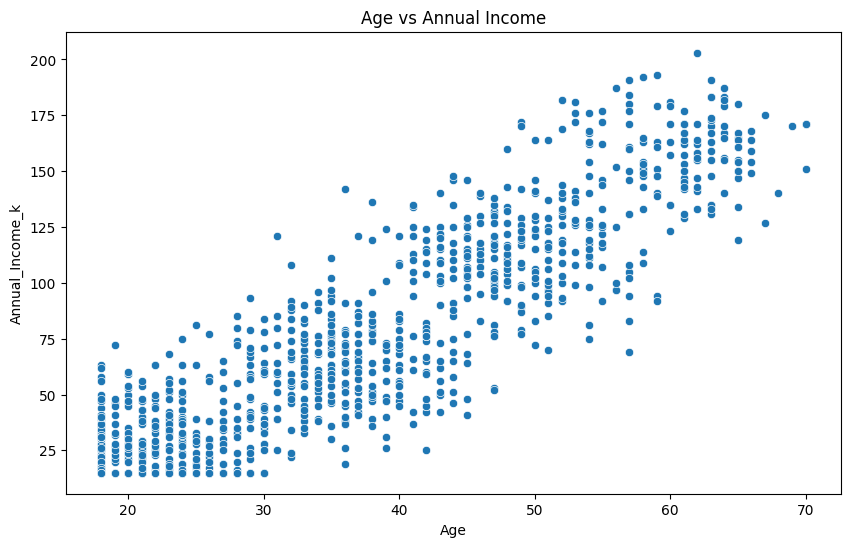

In [3]:
# Exploratory Data Analysis
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Annual_Income_k')
plt.title('Age vs Annual Income')
plt.show()

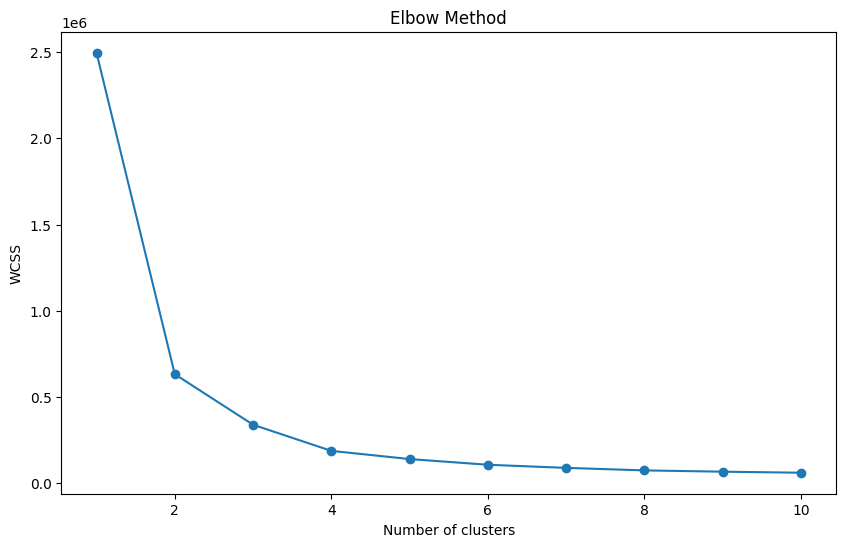

In [4]:
# Elbow Method to find the optimal number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df[['Age', 'Annual_Income_k']])
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
# Applying K-Means with optimal K

def find_optimal_k(wcss):
    """Function to find the optimal number of clusters using the elbow method."""
    kneedle = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
    return kneedle.knee

k = find_optimal_k(wcss)
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df[['Age', 'Annual_Income_k']])

print("Clustering complete.")
print(df.groupby('Cluster').mean())

# Calculate Silhouette Score
score = silhouette_score(df[['Age', 'Annual_Income_k']], df['Cluster'])
print(f"\nSilhouette Score: {score:.4f}")

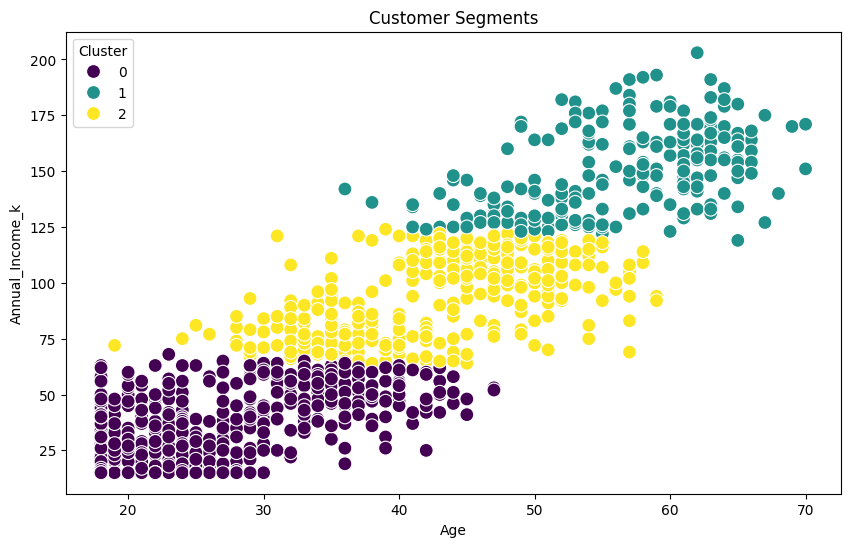

In [6]:
# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Annual_Income_k', hue='Cluster', palette='viridis', s=100)
plt.title('Customer Segments')
plt.show()

In [7]:
# Export the model and the segmented data
joblib.dump(kmeans, 'model/kmeans_model.pkl')
df.to_csv('model/customer_segments.csv', index=False)
print("Model and segmented data exported successfully.")

Model and segmented data exported successfully.
